# 02. Броуновское движение

**Статус:** завершено

В этом ноутбуке мы изучаем стандартное броуновское движение, или винеровский процесс: строим траектории, проверяем распределение приращений, среднее, дисперсию, ковариационную функцию, квадратичную вариацию и время первого достижения барьера.

## Определение и смысл модели

Стандартное броуновское движение $W_t$ — это непрерывный по времени случайный процесс со свойствами:

1. $W_0 = 0$;
2. приращения на непересекающихся интервалах независимы;
3. приращение $W_t - W_s$ имеет нормальное распределение $N(0, t-s)$ при $0 \le s < t$;
4. траектории непрерывны по времени, но почти наверное нигде не дифференцируемы.

Ключевые теоретические характеристики:

$$
\mathbb{E}[W_t] = 0, \qquad \mathrm{Var}(W_t) = t,
$$

$$
\mathrm{Cov}(W_s, W_t) = \min(s,t).
$$

Интуитивно броуновское движение — это предел случайного блуждания при очень маленьких шагах времени и масштабе шага порядка $\sqrt{\Delta t}$. Оно остаётся очень шумным на малых масштабах, но при этом имеет строгую и красивую математическую структуру.

## Импорты и функции

Вся вычислительная логика вынесена в `Scripts/brownian_motion.py`: симуляции, статистики, оценки первого достижения и функции визуализации. В ноутбуке остаются параметры экспериментов, вызовы функций, таблицы и интерпретации.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Scripts.brownian_motion import (
    calculate_empirical_correlation_between_two_brownian_increments,
    calculate_empirical_covariance_matrix_at_selected_times,
    calculate_empirical_mean_and_variance_across_paths,
    calculate_quadratic_variation_for_each_path,
    calculate_total_variation_for_each_path,
    calculate_theoretical_brownian_covariance_matrix,
    calculate_theoretical_mean_and_variance_for_arithmetic_brownian_motion,
    calculate_theoretical_mean_and_variance_for_brownian_motion,
    estimate_first_passage_times_for_brownian_motion_paths,
    extract_brownian_motion_increments_over_interval,
    plot_brownian_increment_distribution_with_normal_density,
    plot_brownian_motion_sample_paths,
    plot_covariance_matrix_heatmaps,
    plot_empirical_and_theoretical_brownian_mean_and_variance,
    plot_first_passage_time_histogram,
    plot_mean_quadratic_and_total_variation_by_grid_size,
    plot_quadratic_variation_distribution,
    summarize_first_passage_simulation,
    simulate_multiple_brownian_motion_paths,
    simulate_multiple_brownian_motion_paths_with_drift_and_volatility,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

## Параметры процесса

Для стандартного броуновского движения главные параметры симуляции такие:

- `final_time` — конечный горизонт наблюдения $T$;
- `number_of_time_steps` — число дискретных шагов сетки;
- `number_of_paths` — количество независимых траекторий;
- `random_seed` — фиксирует генератор случайных чисел для воспроизводимости.

При численной симуляции мы задаём сетку $0=t_0<t_1<\dots<t_n=T$ и генерируем независимые приращения

$$
W_{t_{k+1}} - W_{t_k} \sim N(0, \Delta t).
$$

Чем меньше $\Delta t$, тем более детально мы видим траекторию, но математически сама траектория остаётся крайне нерегулярной.

## 1. Несколько траекторий броуновского движения

Начнём с визуального эксперимента. Одна траектория броуновского движения непрерывна, но она постоянно меняет направление и не похожа на гладкую кривую.

,Конечное значение W(1)
Траектория 1,-0.2935
Траектория 2,-0.9986
Траектория 3,-0.0877
Траектория 4,-3.5516
Траектория 5,-0.0246


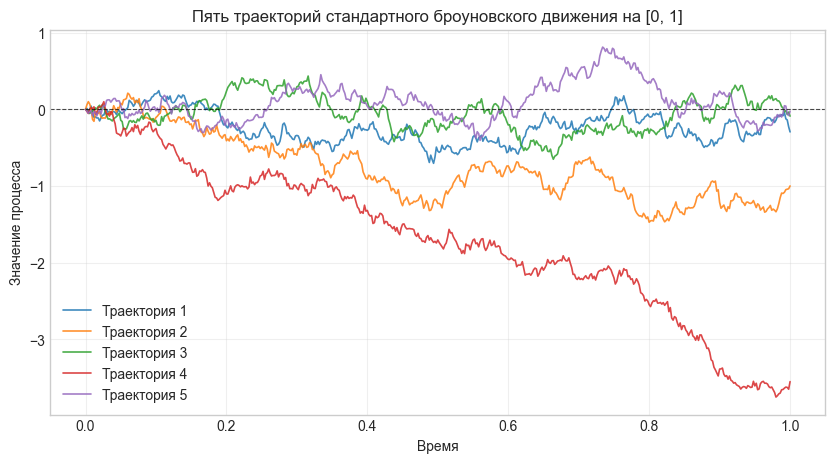

In [2]:
sample_time_grid, sample_brownian_paths = simulate_multiple_brownian_motion_paths(
    number_of_paths=5,
    number_of_time_steps=500,
    final_time=1.0,
    random_seed=42,
)

plot_brownian_motion_sample_paths(
    time_grid=sample_time_grid,
    simulated_paths=sample_brownian_paths,
    number_of_paths_to_plot=5,
    title="Пять траекторий стандартного броуновского движения на [0, 1]",
);

pd.DataFrame(
    {"Конечное значение W(1)": sample_brownian_paths[:, -1]},
    index=[f"Траектория {index}" for index in range(1, 6)],
)

На графике видно сразу две важные вещи. Во-первых, траектории непрерывны: нет скачков, потому что модель строится как предел очень частых малых флуктуаций. Во-вторых, траектории выглядят рваными и постоянно меняют направление.

В воспроизводимом запуске конечные значения пяти траекторий равны примерно `-0.2935`, `-0.9986`, `-0.0877`, `-3.5516` и `-0.0246`. Четвёртая траектория ушла далеко вниз, хотя все траектории имеют одинаковое распределение. Это нормальная ситуация: теория описывает распределение всего ансамбля, а не гарантирует типичность каждой отдельной реализации.

## 2. Среднее и дисперсия по времени

Теперь проверим главные формулы:

$$
\mathbb{E}[W_t] = 0, \qquad \mathrm{Var}(W_t) = t.
$$

Для этого сгенерируем много независимых траекторий и сравним эмпирические средние и дисперсии с теорией.

,Время,Эмпирическое среднее,Теоретическое среднее,Эмпирическая дисперсия,Теоретическая дисперсия
0,0.25,0.0004,0.0,0.2470,0.25
1,0.50,0.0051,0.0,0.4849,0.50
2,1.00,0.0142,0.0,1.0057,1.00


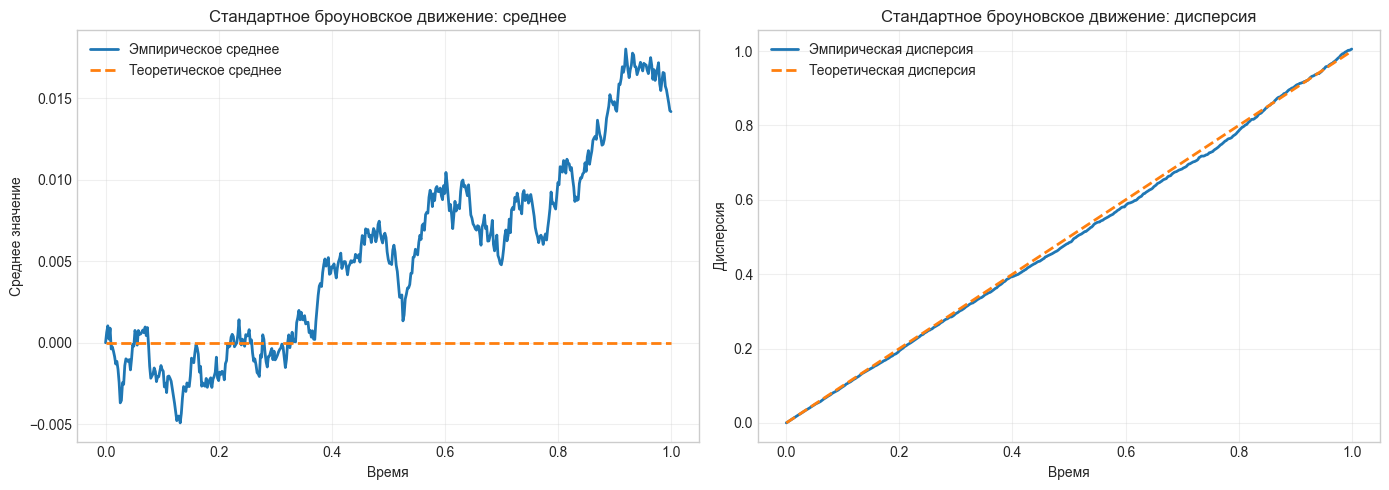

In [3]:
moment_time_grid, moment_brownian_paths = simulate_multiple_brownian_motion_paths(
    number_of_paths=6000,
    number_of_time_steps=500,
    final_time=1.0,
    random_seed=123,
)

empirical_mean, empirical_variance = calculate_empirical_mean_and_variance_across_paths(
    moment_brownian_paths
)
theoretical_mean, theoretical_variance = calculate_theoretical_mean_and_variance_for_brownian_motion(
    moment_time_grid
)

plot_empirical_and_theoretical_brownian_mean_and_variance(
    time_grid=moment_time_grid,
    empirical_mean=empirical_mean,
    empirical_variance=empirical_variance,
    theoretical_mean=theoretical_mean,
    theoretical_variance=theoretical_variance,
    title_prefix="Стандартное броуновское движение",
);

selected_indices_for_moments = [125, 250, 500]
pd.DataFrame(
    {
        "Время": moment_time_grid[selected_indices_for_moments],
        "Эмпирическое среднее": empirical_mean[selected_indices_for_moments],
        "Теоретическое среднее": theoretical_mean[selected_indices_for_moments],
        "Эмпирическая дисперсия": empirical_variance[selected_indices_for_moments],
        "Теоретическая дисперсия": theoretical_variance[selected_indices_for_moments],
    }
)

Эмпирическое среднее почти совпадает с нулевой линией. В моменты `0.25`, `0.50` и `1.00` оно равно `0.0004`, `0.0051` и `0.0142`. Это небольшие случайные отклонения из-за конечного числа траекторий.

Дисперсия растёт почти идеально линейно: в те же моменты получились значения `0.2470`, `0.4849` и `1.0057` против теоретических `0.25`, `0.50` и `1.00`. Поэтому броуновское движение не имеет среднего тренда, но неопределённость состояния растёт пропорционально времени.

## 3. Нормальность, стационарность и независимость приращений

Для броуновского движения приращение на интервале длины $h$ имеет распределение $N(0,h)$ и зависит только от длины интервала, а не от его положения на оси времени. Это свойство называется стационарностью приращений.

Непересекающиеся приращения независимы. В симуляции мы проверим это через корреляцию двух приращений одинаковой длины на разных интервалах.

,Показатель,Значение
0,Среднее приращения,0.0070
1,Дисперсия приращения,0.1990
2,Теоретическая дисперсия,0.2000
3,Корреляция двух непересекающихся приращений,0.0091
4,5%-квантиль приращения,-0.7246
5,Медиана приращения,0.0055
6,95%-квантиль приращения,0.7388


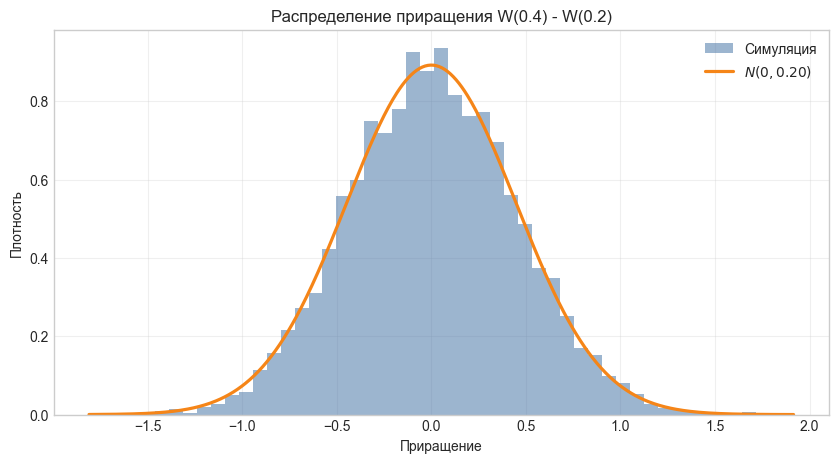

In [4]:
first_increment_sample = extract_brownian_motion_increments_over_interval(
    simulated_paths=moment_brownian_paths,
    start_index=100,
    end_index=200,
)
second_increment_sample = extract_brownian_motion_increments_over_interval(
    simulated_paths=moment_brownian_paths,
    start_index=300,
    end_index=400,
)
increment_interval_length = moment_time_grid[200] - moment_time_grid[100]

increment_correlation = calculate_empirical_correlation_between_two_brownian_increments(
    simulated_paths=moment_brownian_paths,
    first_interval_start=100,
    first_interval_end=200,
    second_interval_start=300,
    second_interval_end=400,
)

plot_brownian_increment_distribution_with_normal_density(
    increments=first_increment_sample,
    interval_length=increment_interval_length,
    title="Распределение приращения W(0.4) - W(0.2)",
);

pd.DataFrame(
    {
        "Показатель": [
            "Среднее приращения",
            "Дисперсия приращения",
            "Теоретическая дисперсия",
            "Корреляция двух непересекающихся приращений",
            "5%-квантиль приращения",
            "Медиана приращения",
            "95%-квантиль приращения",
        ],
        "Значение": [
            first_increment_sample.mean(),
            first_increment_sample.var(),
            increment_interval_length,
            increment_correlation,
            np.quantile(first_increment_sample, 0.05),
            np.quantile(first_increment_sample, 0.50),
            np.quantile(first_increment_sample, 0.95),
        ],
    }
)

Гистограмма приращений хорошо ложится на плотность нормального распределения $N(0, 0.2)$. Эмпирическое среднее равно `0.0070`, а дисперсия `0.1990`, что практически совпадает с теоретической дисперсией `0.2`.

Корреляция между приращениями на интервалах `[0.2, 0.4]` и `[0.6, 0.8]` равна `0.0091`, то есть близка к нулю. Это численно подтверждает независимость непересекающихся приращений. Квантили `-0.7246`, `0.0055` и `0.7388` также выглядят симметрично вокруг нуля, как и должно быть для нормального закона с нулевым средним.

## 4. Дрейф и волатильность: арифметическое броуновское движение

Часто используется расширение стандартного процесса:

$$
X_t = X_0 + \mu t + \sigma W_t.
$$

Здесь $\mu$ — детерминированный дрейф, а $\sigma$ — волатильность, то есть масштаб случайных колебаний. Для такого процесса

$$
\mathbb{E}[X_t] = X_0 + \mu t, \qquad \mathrm{Var}(X_t) = \sigma^2 t.
$$

Этот эксперимент показывает, как параметры меняют не саму структуру шума, а центр и масштаб распределения.

,Время,Эмпирическое среднее,Теоретическое среднее,Эмпирическая дисперсия,Теоретическая дисперсия
0,0.5,1.3993,1.4,0.0800,0.08
1,1.0,1.8055,1.8,0.1596,0.16


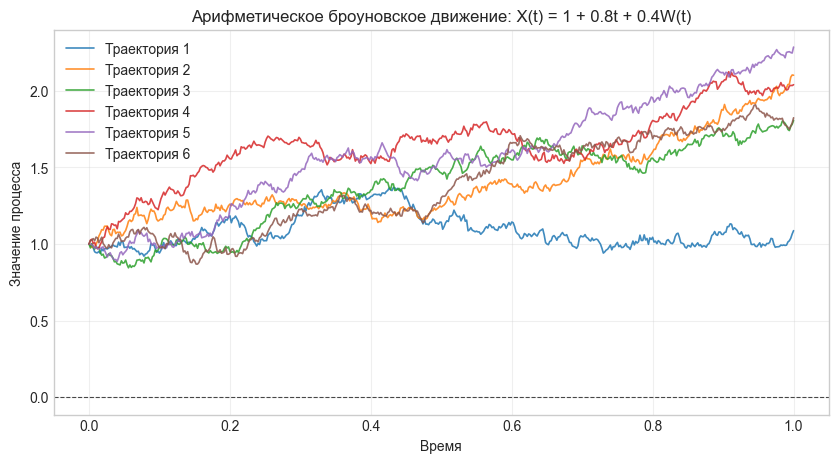

In [5]:
drift_time_grid, drift_brownian_paths = simulate_multiple_brownian_motion_paths_with_drift_and_volatility(
    number_of_paths=6000,
    number_of_time_steps=500,
    final_time=1.0,
    drift=0.8,
    volatility=0.4,
    initial_value=1.0,
    random_seed=321,
)

drift_empirical_mean, drift_empirical_variance = calculate_empirical_mean_and_variance_across_paths(
    drift_brownian_paths
)
drift_theoretical_mean, drift_theoretical_variance = calculate_theoretical_mean_and_variance_for_arithmetic_brownian_motion(
    time_grid=drift_time_grid,
    drift=0.8,
    volatility=0.4,
    initial_value=1.0,
)

plot_brownian_motion_sample_paths(
    time_grid=drift_time_grid,
    simulated_paths=drift_brownian_paths[:6],
    number_of_paths_to_plot=6,
    title="Арифметическое броуновское движение: X(t) = 1 + 0.8t + 0.4W(t)",
);

pd.DataFrame(
    {
        "Время": [drift_time_grid[250], drift_time_grid[500]],
        "Эмпирическое среднее": [drift_empirical_mean[250], drift_empirical_mean[500]],
        "Теоретическое среднее": [drift_theoretical_mean[250], drift_theoretical_mean[500]],
        "Эмпирическая дисперсия": [drift_empirical_variance[250], drift_empirical_variance[500]],
        "Теоретическая дисперсия": [drift_theoretical_variance[250], drift_theoretical_variance[500]],
    }
)

На графике траектории теперь колеблются вокруг растущей линии, потому что $\mu=0.8$ задаёт положительный дрейф. Волатильность $\sigma=0.4$ делает разброс заметным, но не слишком большим.

В момент `t=0.5` эмпирическое среднее равно `1.3993` против теоретического `1.4`, а дисперсия `0.0800` против `0.08`. В момент `t=1.0` получаем среднее `1.8055` против `1.8` и дисперсию `0.1596` против `0.16`. Это показывает, что дрейф управляет центром, а волатильность управляет шириной распределения.

## 5. Ковариационная функция

У броуновского движения значения в разные моменты времени зависимы. Если $s<t$, то $W_t = W_s + (W_t-W_s)$, и первая часть уже содержит всю историю до момента $s$. Поэтому

$$
\mathrm{Cov}(W_s, W_t)=s=\min(s,t).
$$

Проверим это на выбранных временах `0.2`, `0.4`, `0.7` и `1.0`.

,"Эмпирическая Cov(W(t), W(1))","Теоретическая Cov(W(t), W(1))"
t=0.2,0.1966,0.2
t=0.4,0.3972,0.4
t=0.7,0.6965,0.7
t=1.0,1.0057,1.0


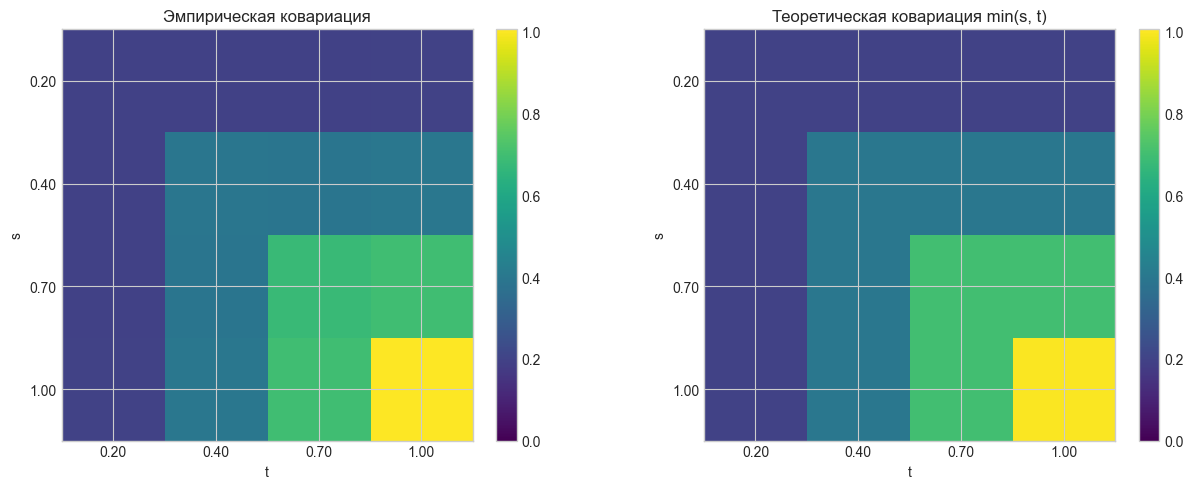

In [6]:
selected_times_for_covariance = [0.2, 0.4, 0.7, 1.0]
selected_covariance_indices, empirical_covariance_matrix = calculate_empirical_covariance_matrix_at_selected_times(
    time_grid=moment_time_grid,
    simulated_paths=moment_brownian_paths,
    selected_times=selected_times_for_covariance,
)
actual_selected_times = moment_time_grid[selected_covariance_indices]
theoretical_covariance_matrix = calculate_theoretical_brownian_covariance_matrix(
    actual_selected_times
)

plot_covariance_matrix_heatmaps(
    selected_times=actual_selected_times,
    empirical_covariance_matrix=empirical_covariance_matrix,
    theoretical_covariance_matrix=theoretical_covariance_matrix,
);

pd.DataFrame(
    {
        "Эмпирическая Cov(W(t), W(1))": empirical_covariance_matrix[-1],
        "Теоретическая Cov(W(t), W(1))": theoretical_covariance_matrix[-1],
    },
    index=[f"t={time:.1f}" for time in actual_selected_times],
)

Тепловые карты почти совпадают. В последней строке, где сравнивается ковариация с $W(1)$, эмпирические значения равны примерно `0.1966`, `0.3972`, `0.6965` и `1.0057`, а теория даёт `0.2`, `0.4`, `0.7` и `1.0`.

Максимальное отклонение по всей матрице в этом запуске около `0.0170`, что мало по сравнению с масштабом ковариаций. Смысл результата такой: чем раньше момент времени, тем меньшая часть будущего значения уже определена общей прошлой историей.

## 6. Квадратичная вариация и негладкость траекторий

Броуновская траектория непрерывна, но почти наверное нигде не дифференцируема. Один из практических способов почувствовать это — квадратичная вариация:

$$
\sum_{k=0}^{n-1} (W_{t_{k+1}}-W_{t_k})^2.
$$

Для обычной гладкой функции такая сумма стремилась бы к нулю при измельчении сетки. Для броуновского движения она стремится к длине интервала, то есть к $T$. На интервале `[0,1]` теоретическое значение равно `1`.

,Число шагов сетки,Средняя квадратичная вариация,Дисперсия оценки,5%-квантиль,Медиана,95%-квантиль
0,50,1.0049,0.0397,0.7008,0.9925,1.3558
1,200,1.0022,0.0102,0.8422,0.9988,1.1763
2,1000,1.0006,0.0019,0.9298,1.0000,1.0743


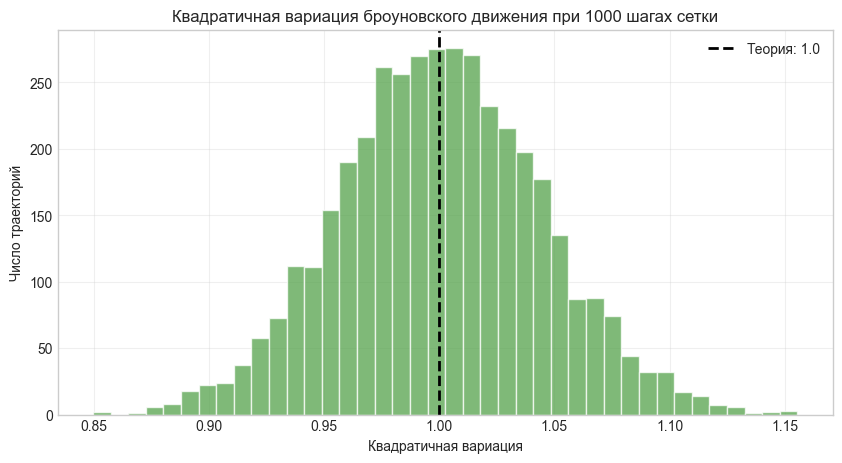

In [7]:
quadratic_variation_summaries = []
quadratic_variation_by_step_count = {}

for number_of_time_steps in [50, 200, 1000]:
    qv_time_grid, qv_paths = simulate_multiple_brownian_motion_paths(
        number_of_paths=4000,
        number_of_time_steps=number_of_time_steps,
        final_time=1.0,
        random_seed=777,
    )
    quadratic_variations = calculate_quadratic_variation_for_each_path(qv_paths)
    quadratic_variation_by_step_count[number_of_time_steps] = quadratic_variations
    quadratic_variation_summaries.append(
        {
            "Число шагов сетки": number_of_time_steps,
            "Средняя квадратичная вариация": quadratic_variations.mean(),
            "Дисперсия оценки": quadratic_variations.var(),
            "5%-квантиль": np.quantile(quadratic_variations, 0.05),
            "Медиана": np.quantile(quadratic_variations, 0.50),
            "95%-квантиль": np.quantile(quadratic_variations, 0.95),
        }
    )

plot_quadratic_variation_distribution(
    quadratic_variations=quadratic_variation_by_step_count[1000],
    final_time=1.0,
    title="Квадратичная вариация броуновского движения при 1000 шагах сетки",
);

pd.DataFrame(quadratic_variation_summaries)

Среднее значение квадратичной вариации остаётся около `1` при всех сетках: `1.0049`, `1.0022` и `1.0006` для `50`, `200` и `1000` шагов. Это совпадает с теорией $[W]_1=1$.

При этом дисперсия оценки уменьшается: `0.039676`, `0.010249` и `0.001949`. Чем мельче сетка, тем стабильнее сумма квадратов приращений около своего предельного значения. Именно это отличает броуновскую траекторию от гладкой функции: маленькие приращения многочисленны, и сумма их квадратов не исчезает, а накапливается до длины временного интервала.

## 7. Первое достижение барьера

Пусть

$$
\tau_a = \inf\{t \ge 0: W_t \ge a\}.
$$

Это момент первого достижения уровня `a`. Для стандартного броуновского движения вероятность достичь положительного уровня `a` до времени `T` выражается через принцип отражения:

$$
\mathbb{P}(\tau_a \le T) = 2\left(1 - \Phi\left(\frac{a}{\sqrt{T}}\right)\right).
$$

Мы возьмём барьер `a=1` и горизонт `T=1`. В симуляции используется дискретная сетка, поэтому очень быстрые пересечения между соседними узлами могут быть пропущены. Из-за этого эмпирическая вероятность обычно немного занижена.

,Показатель,Значение
0,"Доля траекторий, достигших уровня 1 до T=1",0.3023
1,Теоретическая вероятность достижения до T=1,0.3173
2,Среднее время среди достигших,0.5316
3,Медиана времени среди достигших,0.5192
4,Число достигших траекторий,3023.0000
5,25%-квантиль времени достижения,0.3333
6,75%-квантиль времени достижения,0.7233


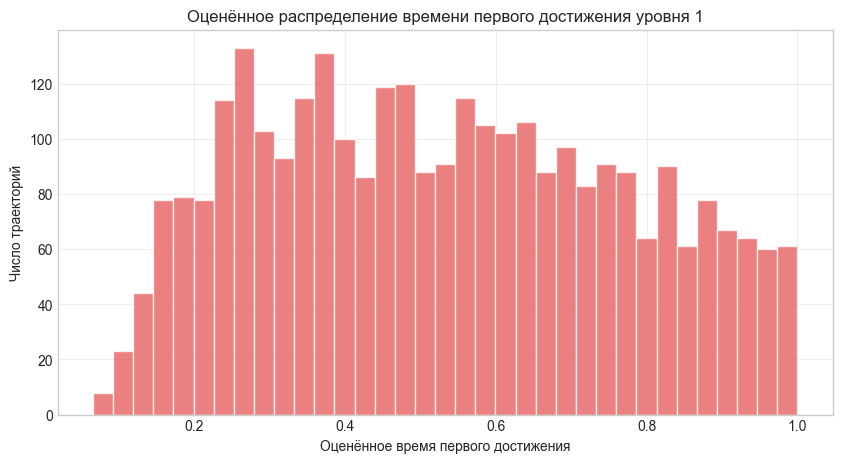

In [8]:
first_passage_time_grid, first_passage_paths = simulate_multiple_brownian_motion_paths(
    number_of_paths=10000,
    number_of_time_steps=1200,
    final_time=1.0,
    random_seed=2026,
)
first_passage_times = estimate_first_passage_times_for_brownian_motion_paths(
    time_grid=first_passage_time_grid,
    simulated_paths=first_passage_paths,
    upper_barrier=1.0,
)
first_passage_summary = summarize_first_passage_simulation(
    first_passage_times=first_passage_times,
    final_time=1.0,
    upper_barrier=1.0,
)

plot_first_passage_time_histogram(
    first_passage_times=first_passage_times,
    title="Оценённое распределение времени первого достижения уровня 1",
);

pd.DataFrame(
    {
        "Показатель": [
            "Доля траекторий, достигших уровня 1 до T=1",
            "Теоретическая вероятность достижения до T=1",
            "Среднее время среди достигших",
            "Медиана времени среди достигших",
            "Число достигших траекторий",
            "25%-квантиль времени достижения",
            "75%-квантиль времени достижения",
        ],
        "Значение": [
            first_passage_summary["fraction_crossed_before_final_time"],
            first_passage_summary["theoretical_fraction_crossed_before_final_time"],
            first_passage_summary["mean_first_passage_time_among_crossed_paths"],
            first_passage_summary["median_first_passage_time_among_crossed_paths"],
            first_passage_summary["number_of_crossed_paths"],
            np.nanquantile(first_passage_times, 0.25),
            np.nanquantile(first_passage_times, 0.75),
        ],
    }
)

В симуляции уровень `1` был достигнут до времени `1` примерно в `0.3023` случаев, а теория даёт `0.3173`. Эмпирическая вероятность немного ниже, и это ожидаемо: мы наблюдаем траекторию только в узлах сетки, поэтому часть пересечений между узлами остаётся невидимой.

Среди траекторий, которые достигли барьера, среднее время достижения равно `0.5316`, медиана `0.5192`, а квантили `25%` и `75%` равны `0.3333` и `0.7233`. Гистограмма показывает, что достижения распределены по всему интервалу, но очень поздние достижения ограничены горизонтом `T=1`.

Практический смысл этого эксперимента: барьерные события для броуновского движения сильно зависят от максимума траектории, а не только от конечного значения $W_T$. Именно поэтому для анализа первого выхода нужны специальные формулы вроде принципа отражения.

## 8. Полная вариация против квадратичной вариации

Квадратичная вариация броуновского движения на `[0,T]` сходится к `T`. Но обычная полная вариация

$$
\sum_k |W_{t_{k+1}}-W_{t_k}|
$$

при измельчении сетки не стабилизируется, а растёт. Это ещё один численный способ увидеть, почему броуновские траектории непрерывны, но не имеют конечной вариации и не ведут себя как гладкие функции.

,Число шагов,Средняя квадратичная вариация,Средняя полная вариация
0,50,0.9877,5.6049
1,200,1.0005,11.2883
2,800,0.9999,22.5630
3,3200,1.0002,45.1414


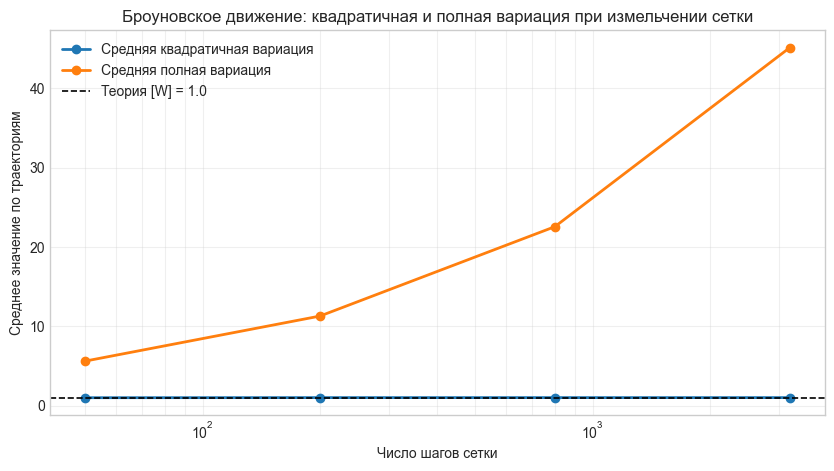

In [9]:
variation_step_counts = np.array([50, 200, 800, 3200])
mean_quadratic_variations = []
mean_total_variations = []

for number_of_time_steps in variation_step_counts:
    _, variation_paths = simulate_multiple_brownian_motion_paths(
        number_of_paths=2500,
        number_of_time_steps=int(number_of_time_steps),
        final_time=1.0,
        random_seed=901 + int(number_of_time_steps),
    )
    mean_quadratic_variations.append(
        calculate_quadratic_variation_for_each_path(variation_paths).mean()
    )
    mean_total_variations.append(
        calculate_total_variation_for_each_path(variation_paths).mean()
    )

mean_quadratic_variations = np.array(mean_quadratic_variations)
mean_total_variations = np.array(mean_total_variations)

plot_mean_quadratic_and_total_variation_by_grid_size(
    number_of_time_steps=variation_step_counts,
    mean_quadratic_variations=mean_quadratic_variations,
    mean_total_variations=mean_total_variations,
    final_time=1.0,
    title="Броуновское движение: квадратичная и полная вариация при измельчении сетки",
);

pd.DataFrame(
    {
        "Число шагов": variation_step_counts,
        "Средняя квадратичная вариация": mean_quadratic_variations,
        "Средняя полная вариация": mean_total_variations,
    }
)

Квадратичная вариация остаётся около `1`: для сеток `50`, `200`, `800`, `3200` средние значения равны примерно `0.9877`, `1.0005`, `0.9999`, `1.0002`. Это согласуется с теорией $[W]_1=1$.

Полная вариация ведёт себя совсем иначе: она растёт примерно от `5.6049` до `45.1414` при измельчении сетки. Значит, броуновская траектория на любом масштабе продолжает накапливать мелкие колебания. Это объясняет, почему её нельзя корректно понимать как обычную гладкую кривую со скоростью $dW_t/dt$.

## Основные выводы

1. Броуновское движение имеет непрерывные, но крайне нерегулярные траектории: визуально они не похожи на гладкие кривые.
2. Эмпирическое среднее остаётся около нуля, а дисперсия растёт линейно по времени, что подтверждает формулы $\mathbb{E}[W_t]=0$ и $\mathrm{Var}(W_t)=t$.
3. Приращения имеют нормальное распределение с дисперсией, равной длине интервала; непересекающиеся приращения в симуляции почти некоррелированы.
4. Дрейф сдвигает среднюю траекторию, а волатильность масштабирует дисперсию: это видно на арифметическом броуновском движении $X_t=X_0+\mu t+\sigma W_t$.
5. Ковариация значений процесса хорошо описывается формулой $\min(s,t)$, потому что будущие значения содержат прошлую историю.
6. Квадратичная вариация на `[0,1]` стабилизируется около `1`, что численно показывает негладкость броуновских траекторий.
7. Вероятность первого достижения барьера хорошо согласуется с принципом отражения, но дискретная сетка немного занижает число обнаруженных пересечений.